---Mangesh S Rajguru From TE 39---


Experiment 4 : Data Analytics I<br>
DataSet      : Boston Housing Dataset (from sklearn)<br>
Objective    : To Predict the house Prices using Linear Regression

In [30]:
#Explaination And Illustration :
# In this Experiment We are Providing the whole dataset of the housing prices to the linear Regression model
# then define feature and target,perform 80% training and 20% testing , then train the model, followed by making predictions and
# evaluating the model and  finally plotting the graph showing the diffrence between the actual and predicted prices

In [31]:
# Steps :1) Import Libraries 
#        2) Load the dataset california housing
#           and make it into a Datframe , create one extra column for the output feature "Price" and describe the dataset 
#        3) Define Features and Target 
#           Where we put features on the X axis and target on the Y axis as price
#        4) Split into train and test
#           Where we train the model 80% and test it on 20%
#        5) Train the model
#           Here, we provide the dataset to the empty model and start the training
#        6) Make Predictions
#           Here, we gave the model x values and got y values
#        7) Evaluate the model
#           Here, we compare the actual result and predicted result, and see the gap that how much wrong predictions our model did 
#        8) Plot Actual Vs Predicted

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing  # Boston is deprecated, use California
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [33]:
# STEP 1: Load Dataset
# As  the Boston Dataset has been removed form the sktLarn , we are using the califormia Housing 
# which is similar for predicting house prices

housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
# lets add a new dedicated column for the price
df['Price'] = housing.target

print("Dataset Loaded!")
print(f"Shape: {df.shape}")
print("\nFirst 5 rows:")
print(df.head())

print("\nBasic Statistics:")
print(df.describe())

Dataset Loaded!
Shape: (20640, 9)

First 5 rows:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  Price  
0    -122.23  4.526  
1    -122.22  3.585  
2    -122.24  3.521  
3    -122.25  3.413  
4    -122.25  3.422  

Basic Statistics:
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.

In [34]:
# Step 2: Define Features and Target

# lets keep everything on x axis , and drop price column
X = df.drop('Price', axis=1)  
# and drop everything on y axis except price column
y = df['Price']    


# so simply this means that the X is the input column , where we will provide the input features and 
# y is the output column, which shows the price  thus acting as the Independent and Dependent Variables
print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")


Features shape: (20640, 8)
Target shape: (20640,)


In [35]:
# STEP 3: Split into Train and Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# This means that 80% training and 20% testing
print(f"\nTraining samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")


Training samples: 16512
Testing samples: 4128


In [36]:
# Step 4: Train the Model
model = LinearRegression()
model.fit(X_train, y_train)
# here simple we took an empty model and feed it with the data on x and y
print("\n Model Trained!")


 Model Trained!


In [37]:
# STEP 5: Make Predictions
y_pred = model.predict(X_test)
# so here we gave the model x values and got y values

In [38]:
# STEP 6: Evaluate the Model
mse = mean_squared_error(y_test, y_pred)
# this measures how wrong our predictions are
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
# this tells that how well the model fits the data

print("\n Model Evaluation")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R² Score: {r2:.4f}")


 Model Evaluation
Mean Squared Error (MSE): 0.5559
Root Mean Squared Error (RMSE): 0.7456
R² Score: 0.5758


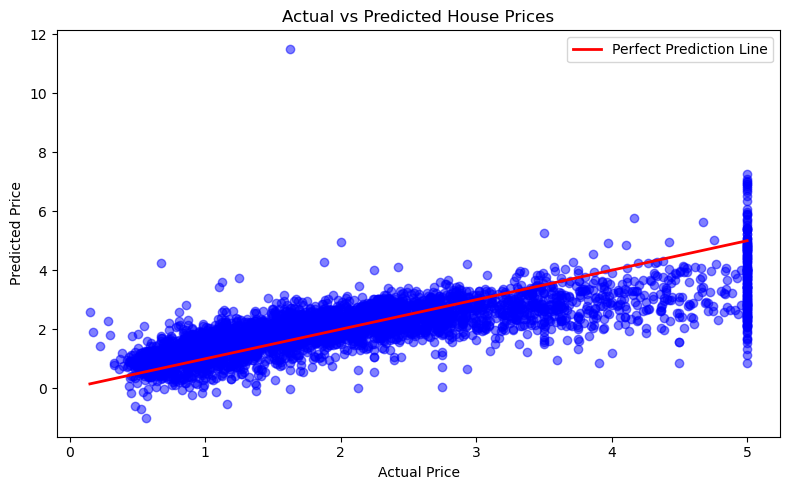

Plot saved!


In [39]:
# STEP 7: Plot Actual vs Predicted
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, color='blue', alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linewidth=2, label='Perfect Prediction Line')
# draws a red straight line
# this is the PERFECT prediction line
# if all dots are ON this line = perfect model
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted House Prices')
plt.legend()
plt.tight_layout()
plt.savefig('exp4_linear_regression.png')
plt.show()
print("Plot saved!")
# here each blue dot is a house

In [40]:
# STEP 8: Show Coefficients
coef_df = pd.DataFrame({
    'Feature': housing.feature_names,
    'Coefficient': model.coef_
})
# so see in the y=mx+c , c is the coeficient , and it tells that how much values changed by changing the feature
print("\nModel Coefficients:")
print(coef_df)
print(f"\nIntercept: {model.intercept_:.4f}")


Model Coefficients:
      Feature  Coefficient
0      MedInc     0.448675
1    HouseAge     0.009724
2    AveRooms    -0.123323
3   AveBedrms     0.783145
4  Population    -0.000002
5    AveOccup    -0.003526
6    Latitude    -0.419792
7   Longitude    -0.433708

Intercept: -37.0233
